In [1]:
%run "01_Data Loading.ipynb"
%run "03_Feature Engineering.ipynb"
%run "05_Predictive Modeling.ipynb"

All imports successful
Train shape : (2666, 20)
Test  shape : (667, 20)

Column dtypes:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Missing values: 0
All imports successful
Train shape : (2666, 20)
Test  shape : (667, 20)

Column dtypes:
State                      object
Account length              int64
Area code                   int64
Internati

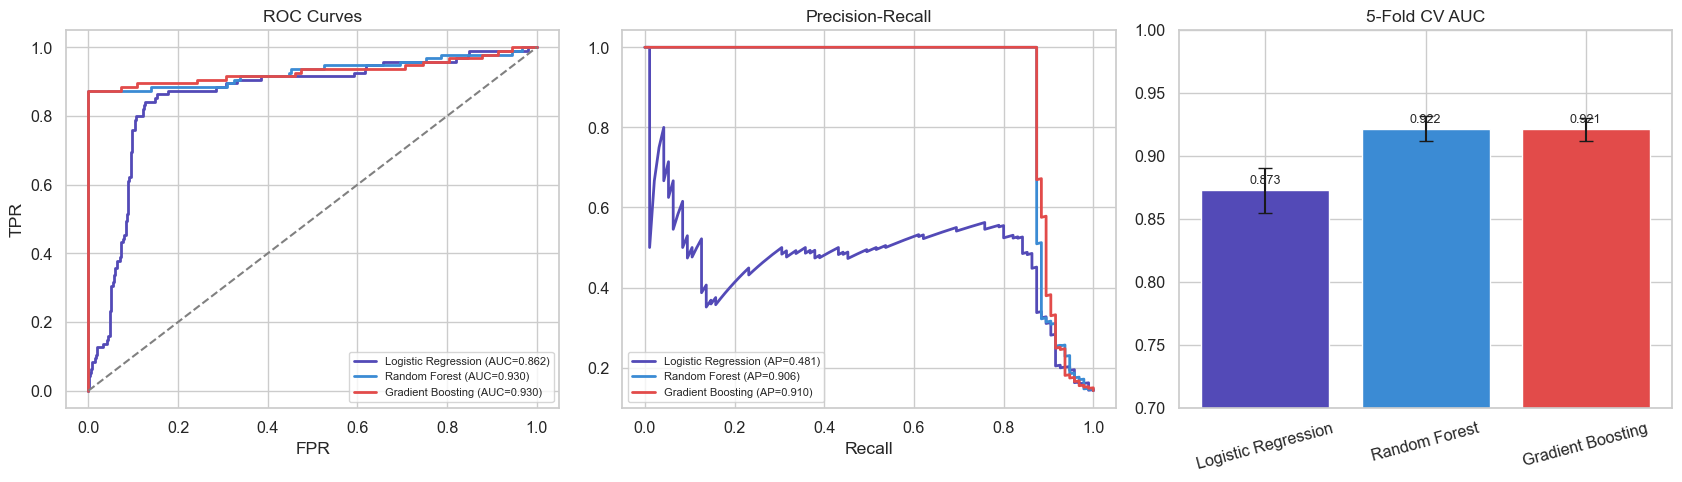

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_m = {'Logistic Regression':'#534AB7','Random Forest':'#3B8BD4','Gradient Boosting':'#E24B4A'}

for name, model in models.items():
    yp = model.predict_proba(X_test_s)[:,1]
    fpr,tpr,_ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    results[name]['auc'] = auc
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors_m[name], linewidth=2)
    prec,rec,_ = precision_recall_curve(y_test, yp)
    ap = average_precision_score(y_test, yp)
    results[name]['ap'] = ap
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=colors_m[name], linewidth=2)

axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].set_title('ROC Curves')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=8)
axes[1].set_title('Precision-Recall'); axes[1].set_xlabel('Recall'); axes[1].legend(fontsize=8)

names = list(results.keys())
bars = axes[2].bar(names, [results[n]['cv_mean'] for n in names],
                   yerr=[results[n]['cv_std'] for n in names], capsize=5,
                   color=[colors_m[n] for n in names], edgecolor='white')
axes[2].set_title('5-Fold CV AUC'); axes[2].set_ylim(0.7,1.0)
axes[2].tick_params(axis='x', rotation=15)
for bar, v in zip(bars,[results[n]['cv_mean'] for n in names]):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Best model: Gradient Boosting
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99       572
     Churned       1.00      0.87      0.93        95

    accuracy                           0.98       667
   macro avg       0.99      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667



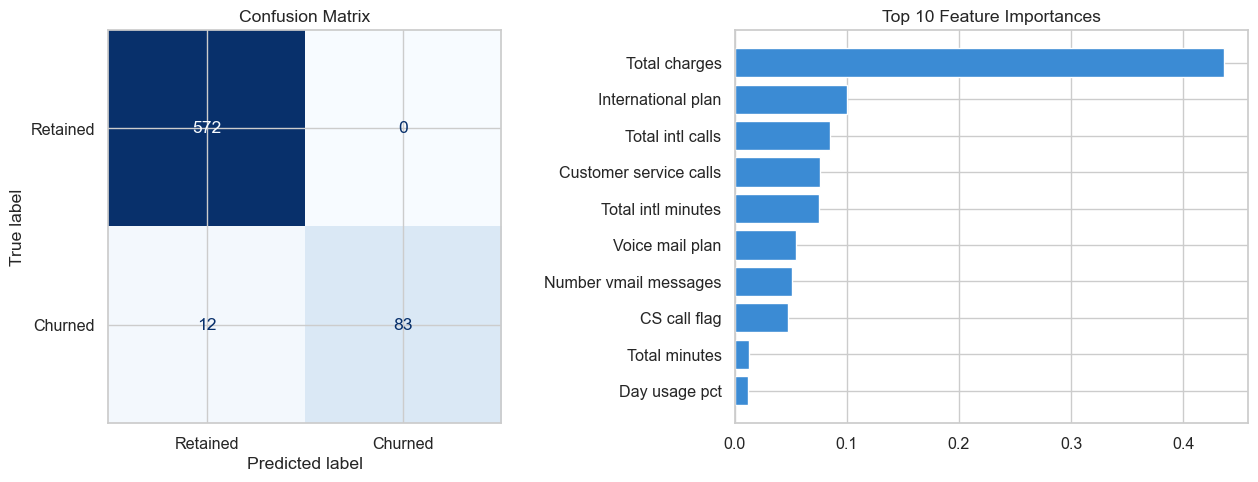

In [3]:
# Choosing best model
best_name  = max(results, key=lambda n: results[n]['auc'])
best_model = models[best_name]
y_pred     = best_model.predict(X_test_s)
y_prob     = best_model.predict_proba(X_test_s)[:,1]

print(f"Best model: {best_name}")
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Retained','Churned'], cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

imp_df = pd.DataFrame({'Feature':X_train.columns,
                       'Importance':best_model.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=True).tail(10)
axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='#3B8BD4', edgecolor='white')
axes[1].set_title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()